# Working code for the biomechzoo Ensembler
This is the plotting library associated with the biomechzoo toolbox. This means that the data inputted into these plotting functions need to be _.zoo files_ or very similarly structured as nested dictionaries.

In [6]:
import os
# import statements
from ensembler import Ensembler
from plot_spec import PlotSpec
# line plot and event renderers
from renderers import IndividualLinesRenderer, MeanSDRenderer, EventOverlayRenderer
from renderers import ViolinRenderer, BlandAltmanRenderer, ScatterRenderer
# combiner renderers
from renderers import CompositeRenderer
from helpers import ConditionSpec, ConditionSource

### Example of setting up the structure

In [16]:
# Set up variables.
import os
current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))
fld = os.path.join(project_root, 'data', 'sample_study', 'normalized')

spec = ConditionSpec(source = ConditionSource.CHANNEL, conditions = ['Straight', 'Turn'],  channel_map = {'Straight': 'RightAnklePower', 'Turn': "RightAnklePower"})
channels = ['RightAnklePower']
# str_match = [r"\b\d{3}[A-Z]{2}\b", r"\b\d{3}[A-Z]{3}\b"]
subj_list = [name for name in os.listdir(fld) if os.path.isdir(os.path.join(fld, name))]
events = ['max']
rows = 1
cols = 3

### Example of individual line plots, events overlay and mean +/- standard deviation plots
Immediatly assigning it to a figure

In [17]:
lines_and_events = CompositeRenderer(IndividualLinesRenderer(), EventOverlayRenderer())
fig = (Ensembler( in_folder=fld, channels=channels, n_rows=rows, n_cols=cols, subj_list=subj_list, condition_spec=spec)
       .add_subplot(PlotSpec('RightAnklePower', 'Straight', companions=['Turn'], row=1, col=1, renderer=IndividualLinesRenderer()))
       .add_subplot(PlotSpec('RightAnklePower_w_events', 'Straight',companions=['Turn'], row=1, col=2, renderer=lines_and_events, events=events))
       .add_subplot(PlotSpec('RightAnklePower_avr', 'Straight', companions=['Turn'], row=1, col=3, renderer=MeanSDRenderer()))
       .build(title='Right Knee Angles (sagittal) - Straight vs Turn')
       )
fig.show()


Built up individually and with all subjects
and adding the x- and y-labels

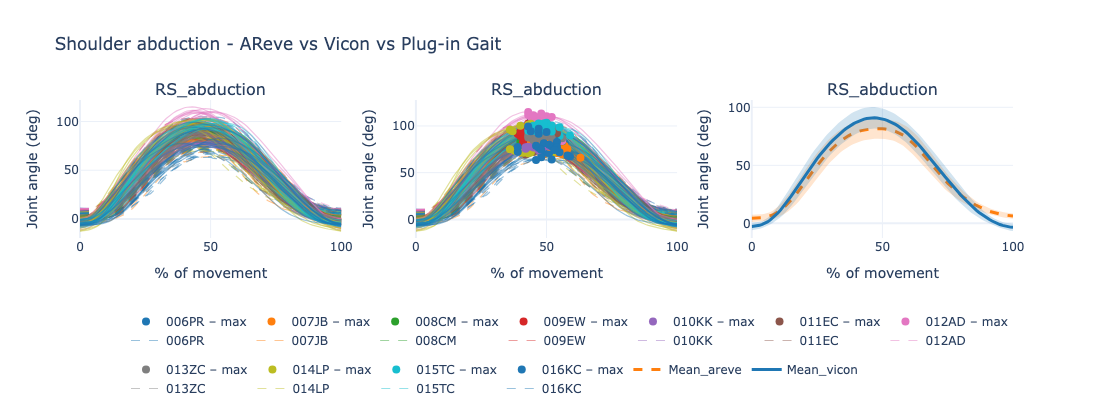

In [4]:
str_match = [r"\b\d{3}[A-Z]{2}\b", r"\b\d{3}[A-Z]{3}\b"]
lines_and_events = CompositeRenderer(IndividualLinesRenderer(), EventOverlayRenderer())
ens = Ensembler( in_folder=fld, channels=channels,
                 n_rows=rows, n_cols=cols,
                 str_match=str_match, condition_spec=spec)
ens.add_subplot(PlotSpec('RS_abduction', "areve", companions=["vicon"],
                         row=1, col=1, renderer=IndividualLinesRenderer(),
                         x_label="% of movement", y_label="Joint angle (deg)"))
ens.add_subplot(PlotSpec('RS_abduction', "areve", companions=["vicon"],
                         row=1, col=2, renderer=lines_and_events, events=events,
                         x_label="% of movement", y_label="Joint angle (deg)"))
ens.add_subplot(PlotSpec('RS_abduction', "areve", companions=["vicon"],
                         row=1, col=3, renderer=MeanSDRenderer(),
                         x_label="% of movement", y_label="Joint angle (deg)"))


fig = ens.build(title="Shoulder abduction - AReve vs Vicon vs Plug-in Gait")
fig.show()

## Extras
The returned fig from the ensembler allows the user all the functionality of plotly figures.
e.g. add annotations to the plot

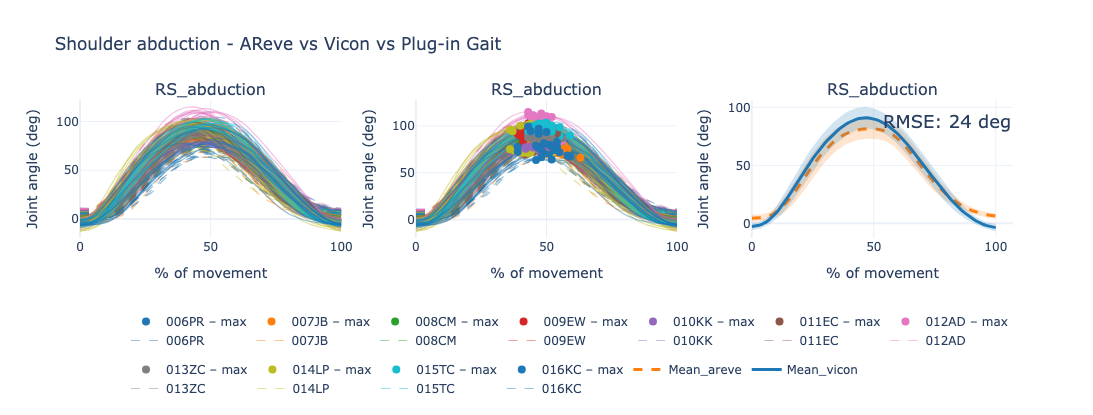

In [5]:
fig.add_annotation(x=80, y=80, showarrow=False,
            text="RMSE: 24 deg",
            yshift=10, font=dict(size=18), row=1,col=3)

## Example violin plot.
Condition is now set on the FOLDER level.

In [6]:
# Set up variables
fld = "/Users/Werk/Documents/Postdoc-McGill/breast-reduction/data/stats"
spec = ConditionSpec(
    source = ConditionSource.FOLDER,
    conditions = ["Pre-surgery", "Post-surgery"]
)

channels = ['ax_pelvis_tilt_corr']
str_match = [r"\b\d{3}[A-Z]{2}\b", r"\b\d{3}[A-Z]{3}\b"]
events = ['impact_peak_mean', 'loading_rate_mean']
rows = 1
cols = 3


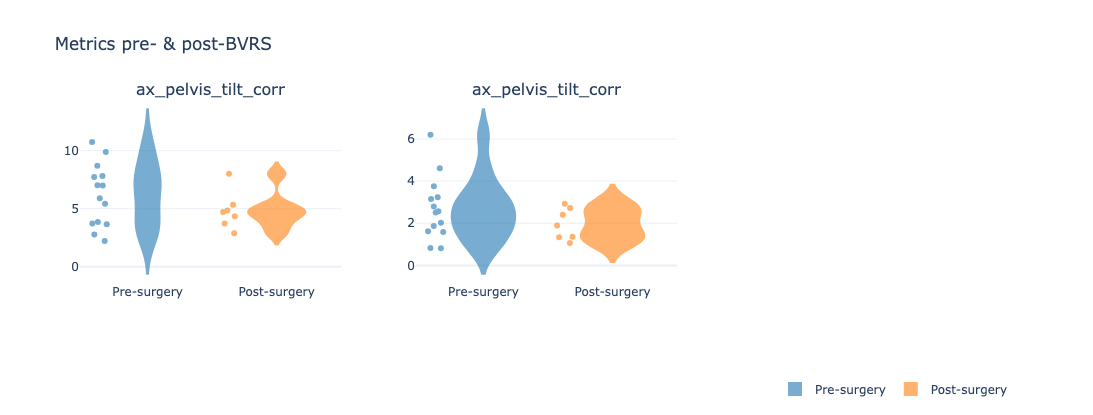

In [7]:
fig = (
    Ensembler(
        in_folder=fld,  channels=channels,
        n_rows=rows,  n_cols=cols,
        str_match=str_match,
        condition_spec=spec,
        events=events)
    .add_subplot(PlotSpec(
        channel="ax_pelvis_tilt_corr",
        condition = "Pre-surgery", companions = ["Post-surgery"],
        row=1, col=1,
        renderer=ViolinRenderer(),
        events=['impact_peak_mean'],)
    )
    .add_subplot(PlotSpec(
        channel="ax_pelvis_tilt_corr",
        condition="Pre-surgery", companions=["Post-surgery"],
        row=1, col=2,
        renderer=ViolinRenderer(),
        events=['loading_rate_mean'])
    )
    .build(title="Metrics pre- & post-BVRS")
)
fig.show()

## Example Scatter plot with regression line and Band-Altman plot
The show_subjects operator allows users to plot the individual subject colors in the markers. Might make it useful to figure out individual trends.

In [8]:
fld = "/Users/Werk/Documents/Postdoc-McGill/areve-mcgill/data/Phase2/17-Stats"

spec = ConditionSpec(
    source     = ConditionSource.CHANNEL,
    conditions = ["vicon", "areve", 'pig'],
    channel_map = {
        "vicon": "RS_abduction_vicon",
        "areve": "RS_abduction_areve",
        "pig" : "RS_abduction_pig",
    }
)
channels = ['RS_abduction']
str_match = [r"\b\d{3}[A-Z]{2}\b", r"\b\d{3}[A-Z]{3}\b"]
# subj_list = ["001CEJ"]
events = ["max"]
rows = 1
cols = 3

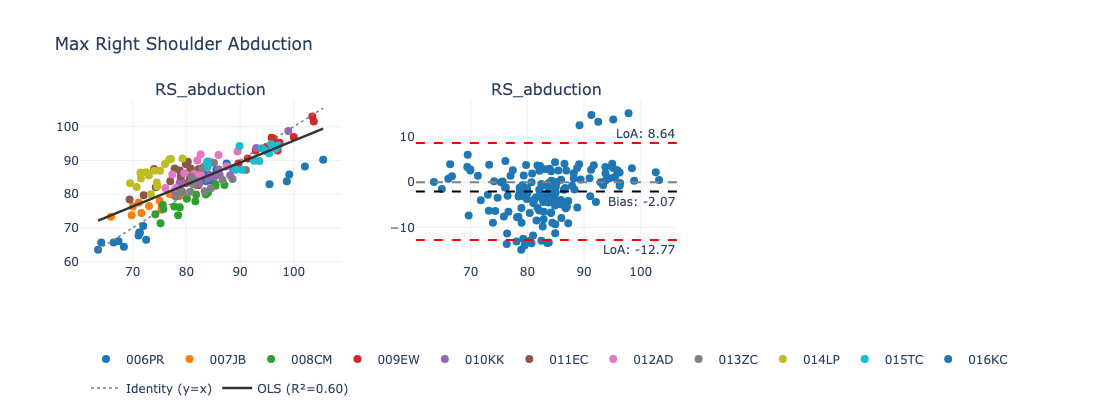

In [9]:
fig = (
    Ensembler(in_folder=fld, channels=channels, n_rows= rows, n_cols =cols, str_match=str_match, condition_spec=spec)
    .add_subplot(PlotSpec(channel='RS_abduction',
                          condition="areve", companions=["pig"],
                          row=1, col=1,
                          renderer=ScatterRenderer(regression_line= True, show_subjects = True), events=events))
    .add_subplot(PlotSpec(channel='RS_abduction',
                          condition="areve", companions=["pig"],
                          row=1, col=2, renderer=BlandAltmanRenderer(use_events= True, show_subjects=False), events=events))
    .build(title="Max Right Shoulder Abduction")
)

fig.show()

In [10]:
spec = ConditionSpec(
    source=ConditionSource.CHANNEL,
    conditions=["vicon", "areve", 'pig'],
    channel_map={
        "vicon": "RS_abduction_vicon",
        "areve": "RS_abduction_areve",
        "pig": "RS_abduction_pig",
    }
)
channels = ['RS_abduction']
str_match = [r"\b\d{3}[A-Z]{2}\b", r"\b\d{3}[A-Z]{3}\b"]
# subj_list = ["001CEJ"]
events = ["rmse_vicon"]
rows = 1
cols = 3


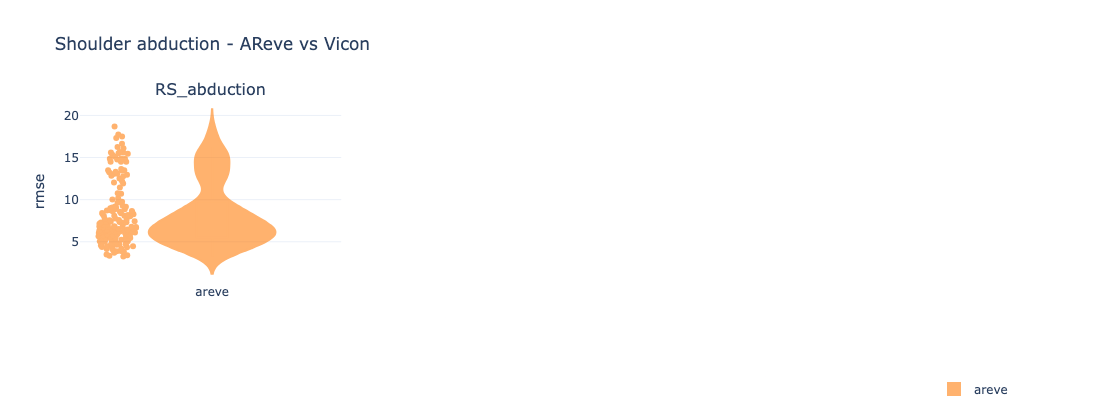

In [11]:
fig = (
    Ensembler(in_folder=fld, channels=channels, n_rows = rows,  n_cols =cols,
              str_match=str_match, condition_spec=spec)
    .add_subplot(PlotSpec(channel='RS_abduction',  condition="areve",
                          row=1, col=1, y_label="rmse",
                          renderer=ViolinRenderer(), events=events))
    .build(title="Shoulder abduction - AReve vs Vicon", )
)
fig.show()